# <b> Telco Customer Churn Analysis </b>
## 통신사 고객 이탈 분석

---

#### **▣ 프로젝트 요약(Project Overview)**
**목표(Goal)**
* 통신사 고객 이탈 요인을 분석하고 이탈 방지 전략 수립 시 참고할 인사이트를 도출한다.

**데이터셋(Dataset)**
* Telco Customer Churn Dataset(IBM sample dataset)

**분석 방법(Method)**
* 로지스틱 회귀(Logistic Regression)

**주요 시사점(Key Findings)**
* 가입 기간(`tenure`)이 길수록 이탈 가능성이 낮다.
* Fiber optic 인터넷 서비스 이용 고객에서 이탈 신호가 높게 나타났다.
* 누적 비용(`TotalCharges`)이 높은 고객군에서 이탈 경향이 관측된다.

---

#### <b>▣ 목차(Table of Contents)</b>
1. 문제 정의(Problem Definition)
2. 데이터 개요(Dataset Overview)
3. 분석 절차(Analysis Approach & Process)
    * 탐색적 데이터 분석(EDA, Exploratory Data Analysis)
    * 데이터 전처리(Feature preprocessing)
    * 모델링(Modeling: Logistic Regression)
    * 모델링 평가(Model Evaluation: Confusion Matrix & Recall)
4. 해석 및 실험 제안(Interpretation & Experiment Ideas)
5. 한계 및 시사점(Limitations & Implications)

---

## <b> 1. 문제 정의(Problem Definition)

통신 산업에서의 **'고객 이탈(Customer Churn)'은 매출 감소로 직결되는 핵심 비즈니스 문제**이다.<br>
본 분석은 통신사 고객 데이터를 활용하여 **이탈과 관련된 주요 요인을 탐색하고,<br>
모델링을 통해 이탈 방지 전략 수립 시 참고할 수 있는 인사이트를 도출하는 것**을 목표로 한다.

---

## <b> 2. 데이터 개요(Dataset Overview)

* **데이터셋:** Telco Customer Churn Dataset(IBM sample dataset)
* **고객 수:** 7,000명 이상
* **타겟 변수:** Churn (Yes / No)
* **주요 설명 변수 구성**
  - 고객 인구통계 정보 (성별, 고령자 여부, 파트너 유무, 부양자 유무)
  - 서비스 이용 정보 (전화 서비스, 인터넷 서비스, 부가 서비스 사용 여부)
  - 계약 및 결제 관련 정보 (계약 유형, 결제 방식, 청구 방식, 요금)

---

## <b>3. 분석 절차(Analysis Approach & Process)</b>

분석에 사용한 데이터는 Telco Customer Churn 공개 데이터셋이며,<br>
아래와 같이 CSV 파일을 불러와 분석을 진행하였다.

In [33]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

### <b> 3-1. 탐색적 데이터 분석(EDA, Exploratory Data Analysis) </b>

이 단계에서는 고객 이탈과 관련된 패턴을 파악하기 위해 주요 변수들의 분포와 이탈 여부에 따른 차이를 탐색한다.<br>
※ <b>타겟 변수(Churn)의 값이 No 또는 0인 고객은 '유지 고객', Yes 또는 1인 고객은 '이탈 고객'</b>으로 명명함

#### <b>가. 데이터 및 변수의 구성</b>

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


데이터는 **약 7,000명 규모**의 고객 데이터로 구성되어 있으며<br>
설명 변수는 20개로, 범주형 변수(object)와 수치형 변수(float64, int64)가 혼합된 구조이다.<br>
결측치의 경우 위 결과에서 나타나지는 않으나, **TotalCharges 변수가 object 타입으로 저장되어 있어 추가로 확인하였으며 공백 문자열(" ") 형태의 결측값이 일부 존재함**을 확인하였다. 해당 변수는 이후 전처리 단계에서 수치형으로 변환 후 모델링에 포함하였다.<br>
수치형 변수 이상치 여부는 이후 전처리 단계에서 추가로 확인하였다.

#### <b>나. 타겟 변수 Churn의 분포</b>

In [36]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

데이터 상 유지 고객(No), 이탈 고객(Yes)은 73:27 정도로 분포하며, <b>이탈 고객(Yes) 비율은 약 26.5%</b>이다.

#### <b> 다. 계약 관련 핵심 변수</b>

* <b>설명 변수 Contract의 Churn 비율</b>

In [37]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


계약 유형(Contract)별로 유지 고객 및 이탈 고객(Churn)의 비율을 살펴보았을 때,<br>
<b>Month-to-month 계약 고객의 이탈 비율이 42.7%</b>에 달해 타 계약 유형의 이탈 비율보다 상대적으로 높게 나타났다.<br>
이는 전체 고객의 평균 이탈 비율인 26.5%보다도 현저히 높은 수치이다.

* <b>설명 변수 tenure의 분포</b>

In [38]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

가입 기간(`tenure`)의 전체 분포는 위와 같으며,<br>
**최소 0개월부터 최대 72개월(6년)까지 보유한 고객**으로 구성되어 있다.<br>
중앙값(29개월)보다 평균(약 32개월)이 더 크며, 이는 **오른쪽으로 꼬리가 긴 분포**를 뜻한다. (왜도: 양수)<br>
이를 `Churn`별로 나누고 시각화하면 아래와 같다.

In [39]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


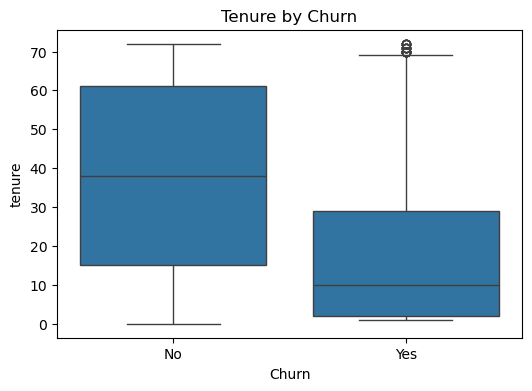

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)
plt.title('Tenure by Churn')
plt.show()

**이탈 고객(Yes)의 가입 기간 중위값은 10개월로,<br>
유지 고객(No)의 가입 기간 중위값인 38개월, 1분위수(25%)의 15개월보다 현저히 적다.<br>**
(이탈 고객(Yes)의 가입 기간 평균은 18개월에 가까우나, 박스플롯에서 보이는 이상치에 영향을 받은 것으로 보인다.)<br>
이는 **이탈 고객(Yes)이 보유기간 10개월 이하에 집중적으로 분포함**을 가리킨다.

#### <b> 라. 서비스 관련 변수</b>

* <b>InternetService의 Churn 비율</b>

In [41]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


* <b>OnlineSecurity의 Churn 비율</b>

In [42]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index')

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


* <b>TechSupport의 Churn 비율</b>

In [43]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


인터넷 서비스(InternetService) 중 **Fiber optic 이용 고객,**<br>
온라인 보안(OnlineSecurity) 및 기술 지원(TechSupport)을 **이용하지 않는 고객**의 경우<br>
각 변수 범주 내에서 **이탈 비율이 약 40% 이상으로 높게 나타났다.**<br>
다만 이러한 서비스 이용 여부는 계약 유형 및 가입 기간과 **상호 연관되어 있을 가능성**이 있어,<br>
이후 모델링 단계에서 **다른 핵심 변수와 함께 해석할 필요가 있다.**

#### <b>마. EDA 요약</b>

탐색적 데이터 분석 결과, 고객 이탈은<br>
<b>계약 유형(Contract)</b>과 <b>가입 기간(tenure)</b>에 따라 뚜렷한 차이를 보였다.<br>
특히 Month-to-month 계약 고객과 가입 기간이 짧은 고객에서 이탈 비율이 높게 나타났으며,<br>
서비스 관련 변수(InternetService, OnlineSecurity, TechSupport) 역시 이탈과 관련된 패턴을 보였다.<br>
다만 서비스 이용 여부는 계약 유형 및 가입 기간과 **상호 연관되어 있을 가능성**이 있어,<br>
이후 단계에서는 이러한 변수들을 함께 고려하여 전처리 및 모델링을 진행한다.

---

### <b>3-2. 데이터 전처리(Feature preprocessing)</b>

본 단계에서는 모델 학습을 위해<br>
**결측치 처리, 변수 타입 정리, 범주형 변수 인코딩, 이상치 검토**를 순차적으로 수행한다.<br>
특히 EDA 단계에서 확인된 사항과 추가 검증이 필요한 변수들을 중심으로 전처리를 진행하였다.

#### <b>가. 결측치 처리(Missing Value Handling)</b>

EDA 단계의 `info()` 결과에서는 명시적인 결측치가 관측되지 않았으나,<br>
`TotalCharges` **변수가 object 타입으로 저장되어 있어 공백 문자열(" ") 형태의 결측 가능성**이 있으므로 추가 확인을 진행하였다.

In [44]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

np.int64(11)

확인 결과, 일부 관측치에서 `TotalCharges` 값이 NaN으로 변환되었으며,<br>
해당 고객들은 **보유기간(tenure)이 0인 신규 고객**으로 확인되었다.

In [45]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges']].head()

,tenure,MonthlyCharges
488,0,52.55
753,0,20.25
936,0,80.85
1082,0,25.75
1340,0,56.05


이는 **요금이 아직 청구되지 않은 상태의 고객**으로 해석 가능하나,<br>
본 분석에서는 이탈 여부 예측을 위해 **요금 누적 정보가 유효한 관측치만을 사용**하고자<br>
해당 관측치는 분석 대상에서 제외하였다.

In [46]:
df = df.dropna(subset=['TotalCharges'])

※ tenure=0 고객은 "초기 고객"으로서 의미 있는 집단일 수 있으나,<br>
본 데이터셋에서는 `TotalCharges`가 구조적으로 정의되지 않아 모델 입력 변수의 일관성을 위해 제외하였다.

#### <b>나. 변수 타입 정리(Data Type Correction)</b>

`TotalCharges`는 수치형 변수로 변환하여 분석에 사용하였다.

In [47]:
df['TotalCharges'].dtype

dtype('float64')

또한 `Churn` 변수는 이진 분류 모델 학습을 위해 0/1로 변환하였다.

In [48]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

#### <b>다. 범주형 변수 인코딩(Categorical Encoding)</b>

식별 목적의 `customerID` 컬럼은 모델 학습에 활용하지 않아 제거하고<br>
모델 학습을 위한 데이터셋(df_model)을 별도로 구성하였다.<br>
이외에도 본 데이터셋에는 다수의 범주형 변수가 포함되어 있어,<br>
로지스틱 회귀 모델 적용을 위해 <b>더미 변수(Dummy Variables)</b>로 변환하였다.<br>
> 더미 변수란, 범주형 변수를 **각 범주별 0/1 값의 새로운 변수로 분해**하는 방식이다.

In [49]:
# 식별자 제거
df_model = df.drop('customerID', axis=1)

# 범주형 변수 선택
cat_cols = df_model.select_dtypes(include='object').columns

# 더미 변수 생성
df_model = pd.get_dummies(
    df_model,
    columns=cat_cols,
    drop_first=True
)

`drop_first=True` 옵션을 사용하여 다중공선성(multicollinearity) 문제를 방지하였다.

In [50]:
df_model.dtypes.value_counts()

bool       26
int64       3
float64     2
Name: count, dtype: int64

변수 제거 및 변환 결과 모델 입력 데이터는 모두 수치형 변수로 구성되었음을 확인하였다.

#### <b>라. 이상치 검토(Outlier Check)</b>

수치형 변수인 `tenure`, `MonthlyCharges`, `TotalCharges`에 대해<br>
기초 통계량을 통해 값의 범위를 확인하였다.

In [51]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


* `tenure`의 경우 최솟값은 1로 결측치가 잘 처리되었고, 최댓값은 72개월로 장기 고객으로 해석 가능하여 **이상치로 판단하지 않았다.**
* `MonthlyCharges`, `TotalCharges`의 경우 위 결과로 보아 음수나 비현실적인 오류값이 관측되지 않아 별도의 이상치 제거는 수행하지 않았다.

---

### <b> 3-3. 모델링(Modeling: Logistic Regression) </b>

본 분석에서는 고객 이탈 여부(Yes/No)를 예측하는 이진 분류 문제의 특성을 고려하여<br>
로지스틱 회귀(Logistic Regression)를 기본 모델로 사용하였다.<br>

#### **가. 전처리 결과 확인**

In [52]:
df_model.shape

(7032, 31)

In [53]:
df_model.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [54]:
df_model.isnull().sum()

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

* 일부 결측 행 제거로 총 7,043행에서 7,032행으로 소폭 감소하였고,
* `TotalCharges`는 수치형(float)로 변환되었으며, `Churn`은 이진 분류를 위해 0/1로 인코딩하였다.
* 범주형 변수는 더미 변수로 변환하였다.
* 결측치는 모두 제거되어 전처리가 완료되었음을 확인하였다.

#### **나. 데이터 분리(Train/Test Split)**

In [55]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

전체 데이터를 학습용(train)과 평가용(test)으로 분리한다.<br>
`Churn`은 불균형 클래스이므로, 클래스 비율을 유지하기 위해 stratify=y를 사용하였다.

#### **다. 변수 스케일링(Feature Scaling: StandardScaler)**

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

로지스틱 회귀는 거리 기반 최적화를 사용하므로,<br>
연속형 변수들의 스케일 차이를 보정하기 위해 StandardScaler를 적용했다.<br>
* fit은 train 데이터에만 수행
* transform은 train/test 모두에 동일한 기준으로 적용<br>

이는 데이터 누수를 방지하기 위함이다.

#### **라. 로지스틱 회귀 모델 학습(Logistic Regression Model Training)**

In [57]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

이진 분류이므로 Logistic Regression을 베이스라인 모델로 사용하였다.<br>
복잡한 모델보다, 계수 해석이 가능하고 기준점이 명확한 모델을 먼저 적용했다.

---

### <b> 3-4. 모델링 평가(Model Evaluation: Confusion Matrix & Recall) </b>

#### **가. 혼동행렬 시각화(Confusion Matrix)**

혼동행렬(confusion matrix)은 모델의 예측 결과를 실제 값과 비교하여<br>
**정확히 맞춘 경우와 잘못 분류한 경우의 분포를 시각적으로 확인**할 수 있게 해준다.<br>
이를 통해 이탈 고객(Churn=1)을 놓치는 경우(False Negative)와<br>
유지 고객(Churn=0)을 이탈로 오분류하는 경우(False Positive)를 구분해 해석할 수 있다.

In [58]:
from sklearn.metrics import confusion_matrix

y_pred = log_reg.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
cm

array([[916, 117],
       [159, 215]])

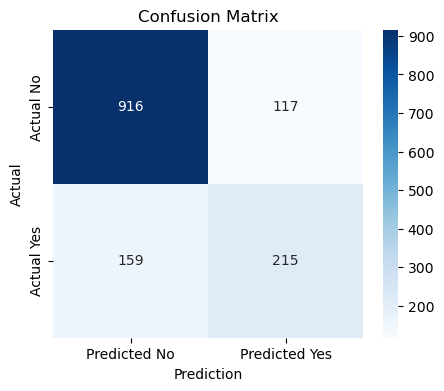

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)

plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

혼동행렬을 통해 모델의 예측 패턴을 확인한 결과<br>
좌측 상단과 같이 **유지 고객(Churn=0)은 비교적 정확하게 분류**하고 있으나,<br>
좌측 하단과 같이 **이탈 고객(Churn=1)의 일부를 유지로 예측하는 경우(False Negative)가 존재**한다.<br>

이는 **모델이 전반적으로 보수적인 예측 경향을 가지며, 이탈 고객을 놓치는 위험**이 있음을 가리킨다.<br>

실제 비즈니스 환경에서는 이탈 고객을 놓치는 비용이 클 수 있으므로,<br>
재현율(Recall)을 높이기 위한 임계값(threshold) 조정이나 다른 모델과의 비교 실험이 필요할 수 있다.

#### **나. 성능 지표 확인**

In [60]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.8038379530916845
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



혼동행렬을 바탕으로 한 수치인 정확도(accuracy)와 함께 precision, recall, f1-score를 확인하여 Churn 고객 탐지 성능을 종합적으로 평가했다.<br>
정확도는 약 80%로 전체 분류 성능은 양호한 편이다.<br>
다만 Churn(1) 클래스의 recall은 0.57로, **실제 이탈 고객 중 약 절반 정도만을 탐지**하고 있다.<br>
**모델이 이탈 고객을 비교적 보수적으로 예측하고 있음**을 다시금 확인할 수 있다.

#### **다. ROC Curve & AUC**

ROC 곡선(Receiver Operating Characteristic Curve)은<br>
분류 임계값(threshold)을 변화시켰을 때 **재현율(True Positive)과 거짓 양성률(False Positive Rate) 간의 관계**를 나타낸다.<br>
이를 통해 모델의 전반적인 분류 성능과 임계값 선택에 따른 trade-off를 확인할 수 있다.

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score

# Churn=1일 확률
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# ROC curve 계산
fpr, tpr, threshold = roc_curve(y_test, y_prob)

# AUC
auc_score = roc_auc_score(y_test, y_prob)
auc_score

np.float64(0.8356727976766699)

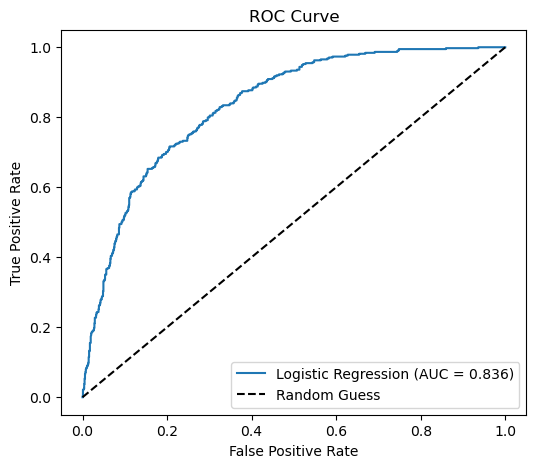

In [62]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

ROC 곡선은 대각선(Random Guess) 대비 위쪽에 위치하며, AUC 값은 약 0.836으로 나타났다.<br>
이는 **본 모델이 임의 분류 대비 이탈 고객을 전반적으로 잘 구분하고 있음**을 의미한다.<br>
ROC 커브를 통해 임계값을 조정할 경우, 이탈 고객 탐지 재현율(Recall)을 높이는 방향의 운영도 가능함을 확인하였다.

---

### <b> 3-5. 모델 해석(Model Interpretation) </b>

#### **계수 분석(Coefficient Analysis)**

In [63]:
import pandas as pd

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values(by='coefficient', ascending=False)

coef_df.head(10)

,feature,coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [64]:
coef_df.tail(10)

,feature,coefficient
18,TechSupport_No internet service,-0.088138
16,DeviceProtection_No internet service,-0.088138
22,StreamingMovies_No internet service,-0.088138
6,Dependents_Yes,-0.105956
19,TechSupport_Yes,-0.118240
13,OnlineSecurity_Yes,-0.136804
24,Contract_One year,-0.310898
25,Contract_Two year,-0.602591
2,MonthlyCharges,-0.851551
1,tenure,-1.347613


로지스틱 회귀 계수는 이탈(Churn) 발생에 대한 각 변수의 상대적 영향 방향을 나타낸다.<br>
* 계수 > 0 : 이탈 가능성을 증가시키는 방향
* 계수 < 0 : 이탈 가능성을 감소시키는 방향<br>

단, 스케일링된 변수 기준이므로 절대적 크기보다 방향성과 상대 비교에 의미를 둔다.

* `tenure`는 가장 강한 음의 계수를 가지며, **장기 고객일수록 이탈 확률이 낮아지는 경향**을 보인다.
* 반면 `InternetService` 중 **'Fiber optic' 옵션**은 가장 강한 양의 계수를 가지며, 해당 옵션 사용자는 **이탈 확률이 증가**한다.
* `MonthlyCharges`는 음의 계수를 가지나, `TotalCharges`는 양의 계수를 가져 **월 요금보다는 누적 요금이 이탈 증가 확률을 증가**시킨다는 것을 알 수 있다.

위의 간략한 계수 분석을 통해 통신 도메인에 비교적 부합하는 결과임을 확인할 수 있으며,<br>
모델과 계수의 설명력을 확보하였으므로 아래 '해석 및 실험 제안'에서 상세 내용을 전개하도록 하겠다.

---

## <b>4. 해석 및 실험 제안(Interpretation & Experiment Ideas)</b>

본 장에서는 **고객 이탈(Churn)에 영향을 미치는 주요 요인**을 정리하고<br>
이를 토대로 **향후 이탈 방지 전략 수립 시 참고할 수 있는 해석과 실험 방향**을 제안한다.

### <b>4-1. 주요 요인</b>

#### **이탈 가능성을 증가시키는 요인** (계수 > 0)
* `InternetService = Fiber optic`
* `TotalCharges`
* 부가 서비스(`MultipleLines`, `StreamingTV`, `StreamingMovies`)
* `PaperlessBilling = No`
* 수동 결제 방식(`PaymentMethod = Electronic check`, `PaymentMehod = Mailed check`)
* `SeniorCitizen = 1`

#### **이탈 가능성을 감소시키는 요인** (계수 < 0)
* `tenure`
* `MonthlyCharges`
* 장기 계약(`Contract = One year`, `Contract = Two year`)
* 부가 서비스(`OnlineSecurity = Yes`, `TechSupport = Yes`)
* `Dependents = Yes`

### <b>4-2. 이탈 방지 전략 수립 시 참고할 수 있는 해석</b>

모델 계수 분석 결과, 고객 이탈은 단일 요인보다는<br>
**서비스 유형, 계약 형태, 비용 구조, 이용 편의성**이 복합적으로 작용한 결과로 해석된다.

#### **가. 주요 서비스 및 부가 서비스**
* `InternetService = Fiber optic`은 가장 높은 양의 계수를 보여,<br> Fiber optic 서비스를 이용하는 고객의 이탈 가능성이 상대적으로 높게 나타났다.
* 인터넷 기반 부가 서비스 중에서는
    * 콘텐츠 소비 성격의 `StreamingTV`, `StreamingMovies` 서비스 이용 고객이 이탈 증가 방향의 계수를 보이나,
    * 보호·지원 성격의 `OnlineSecurity`, `TechSupport` 서비스 이용 고객은 이탈 감소 방향의 계수를 보인다.
* `PhoneService`의 부가 서비스인 `MultipleLines` 이용 고객 역시 이탈 증가 방향의 계수를 보이지만 `InternetService` 관련 계수가 더 높으므로 인터넷 쪽을 우선적으로 살펴보는 것을 권유한다.
* 종합적으로 해석해보면, 이는 `InternetService` 중 **Fiber optic 및 콘텐츠 소비 중심 고객군에서 서비스 품질, 요금 대비 체감 가치에 대한 불만이 누적되었을 가능성이 있음**을 시사한다.

#### **나. 가입 기간 및 계약 기간**
* `tenure`는 가장 강한 음의 계수를 가지며, 가입 기간이 길수록 이탈 가능성이 크게 감소하는 경향을 보였다.
* `Contract = One year`, `Contract = Two year` 역시 이탈 감소 방향으로 작용하여, 장기 계약이 고객 안정화에 중요한 역할을 할 수 있음을 암시한다.
* 이는 **초기 고객을 얼마나 빠르게 '안정 구간'으로 진입시키는지가 이탈 관리의 관건**임을 가리킨다.

#### **다. 요금 구조와 누적 비용**
* 동일한 가입 기간을 가정할 때 `MonthlyCharges`는 이탈 감소 방향의 계수를 가지는 반면 `TotalCharges`는 이탈 증가 방향의 계수를 가져,<br> 월 요금보다 누적 비용 부담이 이탈과 더 밀접하게 관련되어 있음을 보여준다.
* 즉 **단기간의 높은 비용보다는 장기간 누적된 비용에 대한 불만이 이탈로 이어질 가능성**을 시사한다.

#### **라. 청구 및 결제 방식**
* `PaperlessBilling = Yes`와 `PaymentMethod` 중 수동 결제 방식(`Electronic check`, `Mailed check`)이 이탈 증가 방향의 계수를 보였다.
* 다시 말해 **청구 및 결제 과정에서의 편의성, 인지 부담 등의 이슈를 점검할 필요**가 있다.

#### **마. 기타: 인구통계학적 사항**
* `SeniorCitizen = 1`인 고객은 이탈 증가 방향의 계수를,
* `Dependents = Yes`인 고객은 이탈 감소 방향의 계수를 가진다.
* 서비스 이용 과정에서 노년층 고객이 어떤 어려움을 겪는지, 부양 가족이 있는 고객은 어떤 특성을 보이는지 향후 추가로 살펴볼 가치가 있어 보인다.

### <b>4-3. 실험 및 추가 분석 지점 제안</b>

본 분석은 정형 데이터 기반의 분류 모델에 한정되어 있으므로,<br>
다음과 같은 추가 실험 및 분석을 통해 해석의 정밀도를 높일 수 있다.

#### **가. Fiber optic 및 Streaming 서비스 고객 대상 정성 데이터 분석**
* VOC, 고객 문의, 해지 사유 텍스트 데이터 혹은 사용자 인터뷰 등을 활용하여<br> 서비스 품질, 요금, 콘텐츠 만족도와의 연관성 탐색

#### **나. 초기 고객 유지 전략 검증**
* 이탈 고객의 `tenure` 분포를 기반으로 이탈 위험이 높은 초기 구간을 정의하고,
* 해당 구간에서 One year 계약 전환, 부가 서비스 제공 등의 개입 전략 효과 검증

#### **다. 누적 비용 증가 요인 분석**
* `TotalCharges`의 산정 방식을 분해하여 계약 및 계약 변경, 요금 인상, 부가 서비스 추가, 연체, 위약금 등의 요인을 살펴보고 유의미한 개입 지점이 있을지 확인

#### **라. 청구 및 결제 퍼널 점검**
* `PaperlessBilling` 및 `PaymentMethod` 선택지별 이탈률 비교를 통해 결제 과정의 병목 가능성 탐색

---

## <b>5. 한계 및 시사점(Limitations & Implications)</b>

### <b>5-1. 분석의 한계</b>

#### **가. 데이터 범위의 한계**
본 데이터셋은 **'특정 시점'의 고객 계약 정보, 서비스 이용 여부, 요금 정보 등 정형 데이터 중심으로 구성**되어 있으며,<br>
**계약부터 결제, 이탈 등 end-to-end로 사용자 여정을 확인할 수는 없다.** <br>
그러나 실제 고객 이탈에는 서비스 품질 경험, 고객 불만, 경쟁사 이동, 고객 지원 경험 등 정성적인 요인,<br>
서비스 이용 흐름이나 전환 퍼널 등 정량적인 요인이 중요한 영향을 미칠 수 있다.

따라서 고객 VOC, 해지 사유 데이터, 고객 문의 기록 등 정성 데이터와<br>
사용자 여정 중의 퍼널을 살펴볼 수 있다면 이탈 요인을 보다 정밀하게 해석할 수 있을 것으로 보인다.

#### **나. 변수 구조의 한계**
`TotalCharges` 변수는 고객의 가입 기간(`tenure`)과 구조적으로 밀접한 관계를 가지는 누적 지표이다.<br>
그러나 현재 데이터만으로는 **누적 요금 증가가 요금 인상, 서비스 추가, 계약 변경 등 어떤 구체적 요인에서 발생했는지를 확인하기가 어렵다.**

따라서 향후 요금 변동 이력, 서비스 변경 기록 등의 데이터를 활용하면<br>
누적 비용 증가의 원인을 보다 명확히 분석할 수 있을 것이다.

#### **다. 인과 관계 해석의 한계**
본 분석은 로지스틱 회귀 기반의 상관 관계 분석으로,<br>
각 변수와 고객 이탈 간의 관계를 확인할 수는 있으나 **특정 요인이 이탈의 직접적인 원인이라고 단정할 수 없다.** <br>
예를 들어 장기 계약 고객의 이탈률이 낮게 나타났다고 하더라도<br>
장기 계약 자체가 이탈을 줄였는지, 혹은 원래 충성도가 높은 고객이 장기 계약을 선택한 것인지는<br>
본 데이터만으로 구분하기 어렵다는 것에 유의해야 한다.

#### **라. 모델 구조의 한계**
본 분석에서는 해석 가능성을 고려하여 로지스틱 회귀 모델을 사용하였다.<br>
그러나 로지스틱 회귀는 변수 간 선형 관계를 가정하기 때문에<br>
**비선형 패턴이나 복잡한 변수 상호작용을 충분히 반영하지 못할 수 있다.** <br>
향후 의사결정나무(Tree-based) 모델 등을 활용하여 모델 성능, 패턴 탐지 측면에서 비교 분석을 수행할 수 있을 것이다.

### <b>5-2. 주요 시사점</b>

본 분석 결과는 고객 이탈 관리 전략 수립에 있어 다음과 같은 시사점을 제공한다.

**첫째, 고객 가입 초기 구간에서의 관리가 중요하다.** <br>
가입 기간(`tenure`)이 길어질수록 이탈 가능성이 낮아지는 경향이 나타난 만큼,<br>
초기 고객을 안정적인 이용 단계로 빠르게 유도하는 전략이 이탈 관리에 중요한 역할을 할 수 있다.

**둘째, 서비스 경험과 비용 구조에 대한 점검이 필요하다.** <br>
Fiber optic 인터넷 서비스 이용 고객 및 누적 비용(`TotalCharges`)이 높은 고객에서 이탈 증가 신호가 나타난 만큼,<br>
해당 고객군의 서비스 경험 및 요금 구조에 대한 추가적인 분석이 필요하다.